In [1]:
import numpy as np
import pandas as pd

In [ ]:
match = pd.read_csv("data/matches.csv")


In [3]:
print(match.shape)

(756, 18)


In [4]:
match.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [ ]:
delivery = pd.read_csv("data/deliveries.csv")

In [6]:
delivery.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [7]:
teams = [
    'Sunrisers Hyderabad',
    'Mumbai Indians',
    'Royal Challengers Bangalore',
    'Kolkata Knight Riders',
    'Kings XI Punjab',
    'Chennai Super Kings',
    'Rajasthan Royals',
    'Delhi Capitals'
]

In [8]:
match['team1'] = match['team1'].replace({
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad'
})

match['team2'] = match['team2'].replace({
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad'
})

match = match[match['team1'].isin(teams)]
match = match[match['team2'].isin(teams)]

In [9]:
match = match[match['dl_applied'] == 0]


In [10]:
# Correct match columns and rename id → match_id
match_df = match[['id', 'city', 'winner']]
match_df = match_df.rename(columns={'id': 'match_id'})

# Merge delivery with match_df
delivery_df = delivery.merge(match_df, on='match_id')


In [11]:
delivery_df = delivery_df[delivery_df['inning'] == 2]


In [12]:
first_innings = delivery[delivery['inning'] == 1]

target_df = first_innings.groupby('match_id')['total_runs'].sum() + 1
target_df = target_df.rename('target')

delivery_df = delivery_df.merge(target_df, on='match_id')


In [13]:
delivery_df['current_score'] = delivery_df.groupby('match_id')['total_runs'].cumsum()


In [14]:
delivery_df['runs_left'] = delivery_df['target'] - delivery_df['current_score']


In [15]:
delivery_df['balls_left'] = 120 - ((delivery_df['over'] - 1) * 6 + delivery_df['ball'])


In [16]:
delivery_df['player_dismissed'] = delivery_df['player_dismissed'].apply(lambda x: 0 if pd.isna(x) else 1)
delivery_df['wickets_fallen'] = delivery_df.groupby('match_id')['player_dismissed'].cumsum()
delivery_df['wickets'] = 10 - delivery_df['wickets_fallen']


In [17]:
delivery_df['overs_done'] = (120 - delivery_df['balls_left']) / 6
delivery_df['crr'] = delivery_df['current_score'] / delivery_df['overs_done'].replace(0, np.nan)


In [18]:
delivery_df['rrr'] = delivery_df['runs_left'] / (delivery_df['balls_left'] / 6)


In [19]:
delivery_df['result'] = (delivery_df['batting_team'] == delivery_df['winner']).astype(int)


In [20]:
delivery_df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,target,current_score,runs_left,balls_left,wickets_fallen,wickets,overs_done,crr,rrr,result
0,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,1,CH Gayle,Mandeep Singh,A Nehra,0,...,208,1,207,119,0,10,0.166667,6.0,10.436975,0
1,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,2,Mandeep Singh,CH Gayle,A Nehra,0,...,208,1,207,118,0,10,0.333333,3.0,10.525424,0
2,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,3,Mandeep Singh,CH Gayle,A Nehra,0,...,208,1,207,117,0,10,0.500000,2.0,10.615385,0
3,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,4,Mandeep Singh,CH Gayle,A Nehra,0,...,208,3,205,116,0,10,0.666667,4.5,10.603448,0
4,1,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,5,Mandeep Singh,CH Gayle,A Nehra,0,...,208,7,201,115,0,10,0.833333,8.4,10.486957,0


In [21]:
delivery_df.tail()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,target,current_score,runs_left,balls_left,wickets_fallen,wickets,overs_done,crr,rrr,result
72408,11415,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,SR Watson,SL Malinga,0,...,153,152,1,4,5,5,19.333333,7.862069,1.5,0
72409,11415,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,RA Jadeja,SL Malinga,0,...,153,154,-1,3,5,5,19.500000,7.897436,-2.0,0
72410,11415,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,RA Jadeja,SL Malinga,0,...,153,155,-2,2,6,4,19.666667,7.881356,-6.0,0
72411,11415,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,RA Jadeja,SL Malinga,0,...,153,157,-4,1,6,4,19.833333,7.915966,-24.0,0
72412,11415,2,Chennai Super Kings,Mumbai Indians,20,6,SN Thakur,RA Jadeja,SL Malinga,0,...,153,157,-4,0,7,3,20.000000,7.850000,-inf,0


In [22]:
final_df = delivery_df[[
    'batting_team',
    'bowling_team',
    'city',
    'target',
    'runs_left',
    'current_score',
    'balls_left',
    'wickets',
    'crr',
    'rrr',
    'result'
]]


In [23]:
final_df.head()

,batting_team,bowling_team,city,target,runs_left,current_score,balls_left,wickets,crr,rrr,result
0,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,208,207,1,119,10,6.0,10.436975,0
1,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,208,207,1,118,10,3.0,10.525424,0
2,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,208,207,1,117,10,2.0,10.615385,0
3,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,208,205,3,116,10,4.5,10.603448,0
4,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,208,201,7,115,10,8.4,10.486957,0


In [24]:
final_df.tail()

,batting_team,bowling_team,city,target,runs_left,current_score,balls_left,wickets,crr,rrr,result
72408,Chennai Super Kings,Mumbai Indians,Hyderabad,153,1,152,4,5,7.862069,1.5,0
72409,Chennai Super Kings,Mumbai Indians,Hyderabad,153,-1,154,3,5,7.897436,-2.0,0
72410,Chennai Super Kings,Mumbai Indians,Hyderabad,153,-2,155,2,4,7.881356,-6.0,0
72411,Chennai Super Kings,Mumbai Indians,Hyderabad,153,-4,157,1,4,7.915966,-24.0,0
72412,Chennai Super Kings,Mumbai Indians,Hyderabad,153,-4,157,0,3,7.850000,-inf,0


In [25]:
final_df = final_df.sample(final_df.shape[0])

In [26]:
final_df.sample()

,batting_team,bowling_team,city,target,runs_left,current_score,balls_left,wickets,crr,rrr,result
21817,Delhi Daredevils,Chennai Super Kings,Chennai,113,40,73,41,6,5.544304,5.853659,1


In [27]:
#final_df.isnull().sum()

In [28]:
final_df.dropna(inplace=True)

In [29]:
final_df = final_df[final_df['balls_left'] != 0]


In [30]:
X = final_df.drop('result', axis=1)
y = final_df['result']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state = 42)

In [31]:
#X_train.describe()

In [32]:
#y.shape

In [33]:
#X.shape

In [34]:
X_train

,batting_team,bowling_team,city,target,runs_left,current_score,balls_left,wickets,crr,rrr
54389,Chennai Super Kings,Kings XI Punjab,Chandigarh,131,29,102,38,7,7.463415,4.578947
29501,Delhi Daredevils,Deccan Chargers,Delhi,158,156,2,114,9,2.000000,8.210526
44932,Royal Challengers Bangalore,Mumbai Indians,Mumbai,188,90,98,60,8,9.800000,9.000000
39847,Rajasthan Royals,Kings XI Punjab,Chandigarh,146,92,54,74,9,7.043478,7.459459
20446,Rajasthan Royals,Kings XI Punjab,Jaipur,154,44,110,62,9,11.379310,4.258065
...,...,...,...,...,...,...,...,...,...,...
70569,Chennai Super Kings,Mumbai Indians,Chennai,160,128,32,98,8,8.727273,7.836735
13039,Delhi Daredevils,Mumbai Indians,East London,117,100,17,106,10,7.285714,5.660377
21381,Royal Challengers Bangalore,Deccan Chargers,Nagpur,152,73,79,51,8,6.869565,8.588235
71675,Royal Challengers Bangalore,Sunrisers Hyderabad,Bengaluru,180,72,108,47,7,8.876712,9.191489


In [35]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

trf = ColumnTransformer(
    transformers=[
        ('trf', OneHotEncoder(sparse_output=False, drop='first'),
         ['batting_team', 'bowling_team', 'city'])
    ],
    remainder='passthrough'
)


In [36]:
from sklearn.linear_model import LogisticRegression
#from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [37]:
pipe = Pipeline(steps=[
    ('step1', trf),
    ('step2', LogisticRegression(solver='liblinear'))
    #('step2', RandomForestClassifier())
])


In [38]:
pipe.fit(X_train,y_train)


,steps,"[('step1', ...), ('step2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('trf', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [39]:
y_pred = pipe.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score,f1_score, precision_score, r2_score
accuracy_score(y_test,y_pred)
f1_score(y_test,y_pred)
precision_score(y_test,y_pred)
r2_score(y_test,y_pred)

0.1977050991402891

In [41]:
pipe.predict_proba(X_test)[12]


array([0.02287269, 0.97712731])

In [42]:
def match_progression(x_df, match_id, pipe):

    match = x_df[x_df['match_id'] == match_id]

    # FILTER LAST BALL OF EACH OVER + RESET INDEX
    match = match[match['ball'] == 6].reset_index(drop=True)

    temp_df = match[['batting_team', 'bowling_team', 'city',
                     'target', 'runs_left', 'current_score',
                     'balls_left', 'wickets', 'crr', 'rrr']]

    temp_df = temp_df[temp_df['balls_left'] != 0]

    result = pipe.predict_proba(temp_df)

    temp_df['lose'] = np.round(result[:,0] * 100, 1)
    temp_df['win']  = np.round(result[:,1] * 100, 1)

    temp_df['end_of_over'] = range(1, len(temp_df) + 1)

    # RUNS LOST PER OVER
    target = temp_df['target'].iloc[0]
    runs_left = list(temp_df['runs_left'])
    shifted = [target] + runs_left[:-1]
    temp_df['runs_after_over'] = np.array(shifted) - np.array(runs_left)

    # WICKETS LOST PER OVER
    wickets = list(temp_df['wickets'])
    shifted_w = [10] + wickets[:-1]
    temp_df['wickets_fallen'] = np.array(shifted_w) - np.array(wickets)

    # TOTAL RUNS CHASED TILL EACH OVER
    temp_df['total_runs_chased'] = target - temp_df['runs_left']

    # --------- FINAL MATCH WINNER & LOSER ----------
    final_win_prob  = temp_df['win'].iloc[-1]
    final_lose_prob = temp_df['lose'].iloc[-1]

    batting_team = match['batting_team'].iloc[0]
    bowling_team = match['bowling_team'].iloc[0]

    if final_win_prob > final_lose_prob:
        winner_team = batting_team
        loser_team  = bowling_team
    else:
        winner_team = bowling_team
        loser_team  = batting_team

    final = temp_df[['end_of_over', 'runs_after_over',
                     'wickets_fallen', 'total_runs_chased',
                     'lose', 'win']]

    return final, target, winner_team, loser_team


In [43]:
temp_df, target, winner_team, loser_team = match_progression(delivery_df,85, pipe)

print("Target:", target)
print("Winner_team:", winner_team)
print("Loser_team:", loser_team)
temp_df

Target: 145
Winner_team: Deccan Chargers
Loser_team: Chennai Super Kings


,end_of_over,runs_after_over,wickets_fallen,total_runs_chased,lose,win
0,1,3,0,3,72.2,27.8
1,2,1,0,4,77.1,22.9
2,3,11,0,15,68.6,31.4
3,4,9,0,24,62.6,37.4
4,5,6,1,30,74.8,25.2
5,6,20,0,50,53.2,46.8
6,7,8,0,58,48.7,51.3
7,8,12,0,70,38.0,62.0
8,9,7,0,77,35.2,64.8
9,10,1,1,78,57.0,43.0


Text(0.5, 1.0, 'Target-145')

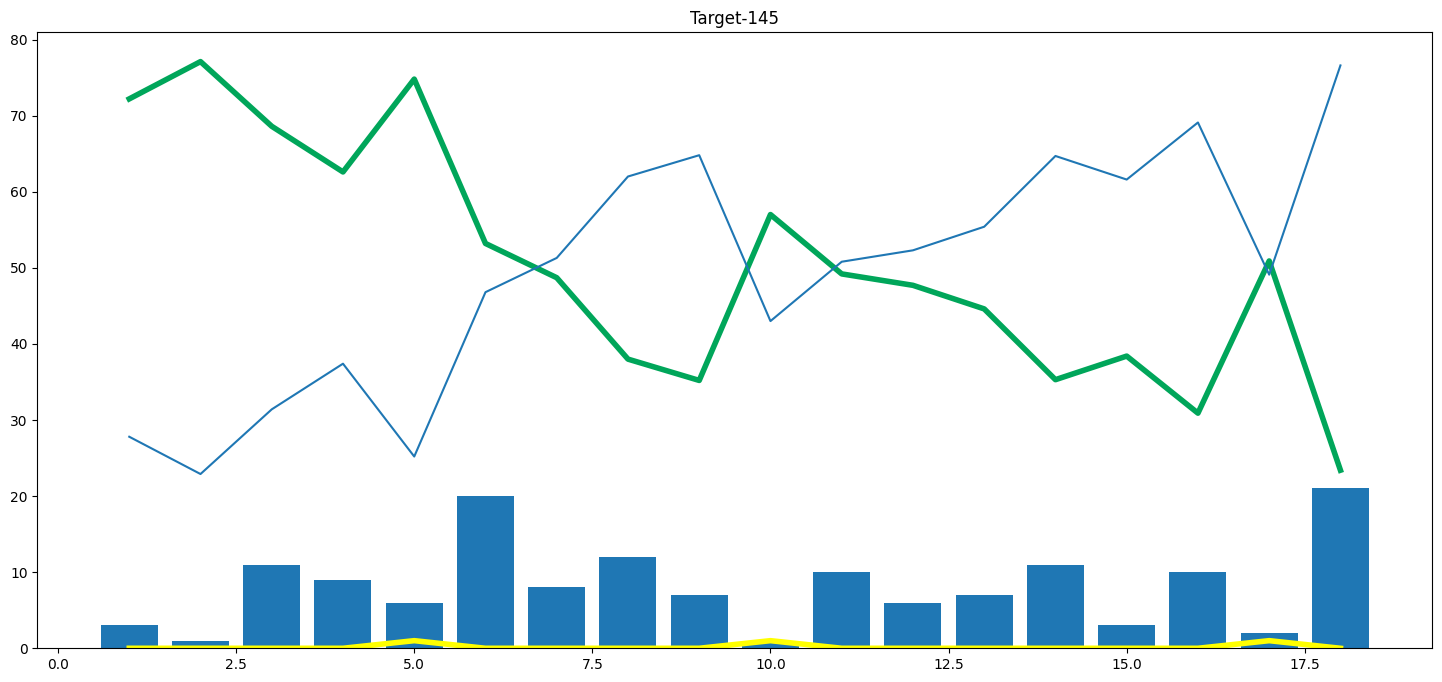

In [44]:
import matplotlib.pyplot as plt
plt.figure(figsize =(18,8))
plt.plot(temp_df['end_of_over'], temp_df['wickets_fallen'],color = 'yellow',linewidth = 4)
plt.plot(temp_df['end_of_over'], temp_df['lose'],color = '#00a65a',linewidth =4)
plt.plot(temp_df['end_of_over'], temp_df['win'])
plt.bar(temp_df['end_of_over'], temp_df['runs_after_over'])
plt.title('Target-' + str(target))

In [45]:
teams

['Sunrisers Hyderabad',
 'Mumbai Indians',
 'Royal Challengers Bangalore',
 'Kolkata Knight Riders',
 'Kings XI Punjab',
 'Chennai Super Kings',
 'Rajasthan Royals',
 'Delhi Capitals']

In [46]:
delivery_df['city'].unique()

array(['Hyderabad', 'Bangalore', 'Mumbai', 'Indore', 'Kolkata', 'Delhi',
       'Chandigarh', 'Jaipur', 'Chennai', 'Cape Town', 'Port Elizabeth',
       'Durban', 'Centurion', 'East London', 'Johannesburg', 'Kimberley',
       'Bloemfontein', 'Ahmedabad', 'Cuttack', 'Nagpur', 'Dharamsala',
       'Visakhapatnam', 'Pune', 'Raipur', 'Ranchi', 'Abu Dhabi',
       'Sharjah', nan, 'Mohali', 'Bengaluru'], dtype=object)

In [47]:
# import pickle
# pickle.dump(pipe,open('pipe.pkl','wb'))
